# Finetune Qwen3 with LLaMA Factory

Please use a **free** Tesla T4 Colab GPU to run this!

Project homepage: https://github.com/hiyouga/LLaMA-Factory

---
## The Scenario

You're a senior engineer at a fast-growing SaaS company. Your support team handles 2,000+ tickets a day — inbound across email, Slack, and your help portal. Today, every ticket touches a human before it reaches the right queue. A triage agent reads it, decides intent, and routes it manually. That's ~3 hours of human time daily, and it scales linearly with your user base.

You fix this by deploying a lightweight classifier at the front of the pipeline. Every ticket hits the model first:

```
bug_report       → engineering queue, P2 Jira ticket opened automatically
access_request   → IT/IAM team, provisioning workflow triggered
billing_inquiry  → finance team, Stripe customer record pulled and attached
feature_request  → product team, backlog item created in Linear
```

The model never writes a response. It reads intent and fires a webhook. The rest of your tooling takes over.

**Why not GPT-4o?**
At 2,000 tickets/day, a frontier model costs $80–120/day just for classification calls — ~$40K/year for a four-class router. Your finetuned 1.5B model runs on a single CPU instance for under $10/month and makes the same call in ~18ms. That's the actual business case for finetuning: not raw capability, but cost and latency at scale on a well-scoped task.

**Why not keyword matching or regex?**
"I can't access my invoice" — billing or access? "The export is broken" — bug or feature request? "You charged me twice and now my account is locked" — both. Natural language is compositional and ambiguous. Rule-based routers fail on negation, multi-intent tickets, and phrasing variation. In practice, keyword routing misclassifies 25–35% of real support volume, which means your automation quietly generates more work than it saves.

A finetuned model learns intent from context. That's the difference between a brittle script and a reliable system component.

---

## Install Dependencies

In [ ]:
%cd /content/
%rm -rf LLaMA-Factory
!git clone --depth 1 https://github.com/hiyouga/LLaMA-Factory.git
%cd LLaMA-Factory
%ls
!pip install -e .[torch,bitsandbytes]

/content
Cloning into 'LLaMA-Factory'...
remote: Enumerating objects: 676, done.
remote: Counting objects: 100% (676/676), done.
remote: Compressing objects: 100% (511/511), done.
remote: Total 676 (delta 156), reused 441 (delta 100), pack-reused 0 (from 0)
Receiving objects: 100% (676/676), 5.37 MiB | 24.01 MiB/s, done.
Resolving deltas: 100% (156/156), done.
/content/LLaMA-Factory
assets/       data/    examples/  MANIFEST.in     README_zh.md   src/
CITATION.cff  docker/  LICENSE    pyproject.toml  requirements/  tests/
CLAUDE.md@    docs/    Makefile   README.md       scripts/       tests_v1/
Obtaining file:///content/LLaMA-Factory
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━

### Check GPU environment

In [ ]:
import torch
try:
  assert torch.cuda.is_available() is True
except AssertionError:
  print("Please set up a GPU before using LLaMA Factory: https://medium.com/mlearning-ai/training-yolov4-on-google-colab-316f8fff99c6")

## Update Identity Dataset

In [ ]:
import json

%cd /content/LLaMA-Factory/

NAME = "Llama-3"
AUTHOR = "LLaMA Factory"

with open("data/identity.json", "r", encoding="utf-8") as f:
  dataset = json.load(f)

for sample in dataset:
  sample["output"] = sample["output"].replace("{{"+ "name" + "}}", NAME).replace("{{"+ "author" + "}}", AUTHOR)

with open("data/identity.json", "w", encoding="utf-8") as f:
  json.dump(dataset, f, indent=2, ensure_ascii=False)

## Prepare Support Ticket Dataset (INPUT REQUIRED)

Run this cell and upload `support_ticket.csv` from your local machine when prompted. This cell creates a stratified 80/20 train/val split, converts the training split to **ShareGPT JSON format**, writes it to `/content/LLaMA-Factory/data/TRAIN.json`, and registers it in `dataset_info.json` so it appears in the LLaMA Board UI under the name `support_tickets`.

In [ ]:
import json
import pandas as pd
from sklearn.model_selection import train_test_split
from google.colab import files

# ── constants ──────────────────────────────────────────────────────────────────
LLAMA_DATA_DIR = "/content/LLaMA-Factory/data"
TRAIN_JSON_PATH = f"{LLAMA_DATA_DIR}/TRAIN.json"
DATASET_INFO    = f"{LLAMA_DATA_DIR}/dataset_info.json"

LABEL2ID = {
    "Support general":   0,
    "Fileservice":       1,
    "O365":              2,
    "EOL":               3,
    "Software":          4,
    "Active Directory":  5,
    "Computer-Services": 6,
}

SYSTEM_PROMPT = (
    "You are an IT helpdesk ticket routing assistant. "
    "Given a support ticket, respond with exactly one of the following categories: "
    "Support general, Fileservice, O365, EOL, Software, Active Directory, Computer-Services."
)

# ── 1. Upload CSV ──────────────────────────────────────────────────────────────
print("Upload support_ticket.csv:")
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]

# ── 2. Load + filter ───────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH).rename(columns={"category_truth": "label"})
df = df[df["label"].isin(LABEL2ID)].sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Loaded {len(df):,} rows")
print(df["label"].value_counts())

# ── 3. Stratified train/val split on the full dataset ─────────────────────────
df_train, df_val = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=42,
)
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
print(f"\nTrain: {len(df_train):,} rows | Val (held-out): {len(df_val):,} rows")
print("\nTrain label distribution:")
print(df_train["label"].value_counts())

# ── 4. Convert train split → ShareGPT JSON ────────────────────────────────────
sharegpt_records = [
    {
        "messages": [
            {"role": "system",    "content": SYSTEM_PROMPT},
            {"role": "user",      "content": f"Support Ticket: {row['text']}"},
            {"role": "assistant", "content": row["label"]},
        ]
    }
    for _, row in df_train.iterrows()
]

with open(TRAIN_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(sharegpt_records, f, indent=2, ensure_ascii=False)
print(f"\nWritten {len(sharegpt_records):,} records → {TRAIN_JSON_PATH}")

# ── 5. Register dataset in dataset_info.json ──────────────────────────────────
with open(DATASET_INFO, "r", encoding="utf-8") as f:
    info = json.load(f)

info["support_tickets"] = {
    "file_name": "TRAIN.json",
    "formatting": "sharegpt",
    "columns":   {"messages": "messages"},
    "tags": {
        "role_tag":      "role",
        "content_tag":   "content",
        "user_tag":      "user",
        "assistant_tag": "assistant",
        "system_tag":    "system",
    },
}

with open(DATASET_INFO, "w", encoding="utf-8") as f:
    json.dump(info, f, indent=2, ensure_ascii=False)
print(f"Registered 'support_tickets' in {DATASET_INFO}")

# ── 6. Save val split for evaluation ──────────────────────────────────────────
VAL_CSV = "/content/val_split.csv"
df_val.to_csv(VAL_CSV, index=False)
print(f"Val split saved → {VAL_CSV}  ({len(df_val):,} rows)")

## Fine-tune model via LLaMA Board (INPUT REQUIRED)
1. Run this cell to start the LLaMA Board server. You should see a public and local URL in the output, open the public URL in a your browser to access the UI.
2. Choose 'Qwen/Qwen3-1.7B-Base' as the base model, and type 'support_tickets' as the dataset. Make sure that you've set the training to lora. You can adjust training hyperparameters as you see fit, but the defaults should be good for a quick test run.
3. Once you finish training, take note of the **Output Dir** path shown in the bottom of this cell (e.g. `train_2026-...`) — you will need it for the next step.
4. Importantly, terminate this cell manually once training completes, as Colab won't know to stop it (this cell is technically a server daemon).

Note: To know that the training has completed, wait in the UI till you see a "training completed" notifcation on your screen or at the bottom of the training logs. Don't worry if you see some "syntax error" noticaition every now and then, this is a known issue with the LLaMA Board UI and doesn't affect training.

This will take a while (usually around 30-60 mins on a T4 GPU, depending on your model and hyperparameters), so feel free to grab a coffee while you wait!

### Hyperparameter Reference

The table below covers every parameter visible in the LLaMA Board Train tab. Use it to decide what to change if your first run underperforms.

Ordered by priority of tuning. Realistically, you only need to tune learning rate, epochs, batch size, and *maybe* LoRA rank. But you're perfectly fine using the defaults for a first run!

| Parameter | What it controls | Too high | Too low |
|-----------|-----------------|----------|---------|
| **Learning rate** | The step size the optimiser takes each update. Controls how aggressively the model updates toward each training example. | Loss spikes or diverges; model "unlearns" general knowledge (catastrophic forgetting) | Loss decreases very slowly; you need many more epochs to converge |
| **Epochs** | How many full passes over the training data the optimiser makes. | Model overfits — memorises training tickets and fails to generalise to new ones | Model underfits — loss is still falling when training stops; accuracy left on the table |
| **Batch size** | Number of samples processed together before each weight update. Larger batches give smoother gradient estimates but use more VRAM. | Runs out of VRAM; or gradients become too smooth and training stalls | Noisy gradient estimates; loss curve is jagged; training is slower wall-clock |
| **LoRA rank (r)** | Dimension of the low-rank matrices injected at each target layer. Higher rank = more trainable parameters = more expressive adapter. | More VRAM, slower training, risk of overfitting on small datasets | Adapter has too little capacity to capture the routing task; accuracy plateaus |
| **Gradient accumulation** | Simulates a larger batch by accumulating gradients over this many steps before updating. Effective batch = batch size × accumulation. | Effective batch becomes so large that small-dataset signal is washed out | Same as low batch size — noisy updates |
| **Cutoff length** | Maximum token length of each training example. Examples longer than this are truncated. | No downside except more VRAM and slower steps | Long tickets get silently truncated; model never sees the full context for complex tickets |
| **Max gradient norm** | Clips the gradient vector to this L2 norm before each update. Prevents a single bad batch from causing a catastrophically large weight update. | Gradients are never clipped; a noisy batch can cause a loss spike | Gradients are clipped too aggressively; effective learning rate is much lower than set; training slows |
| **LR scheduler** | Controls how the learning rate changes over training. `cosine` warms up then smoothly decays to near zero. `linear` decays linearly. `constant` never changes. | N/A — this is a choice, not a magnitude | N/A |
| **Compute type** | Numerical precision during training. `bf16` is standard on modern GPUs (A100, H100); `fp16` for older hardware (T4); `fp32` uses full precision but 2× the VRAM. | N/A — match to your GPU | Using `fp32` on a T4 will likely OOM |



In [ ]:
%cd /content/LLaMA-Factory/
!GRADIO_SHARE=1 llamafactory-cli webui

---
## Review Training — Loss Curve (INPUT REQUIRED)

Before merging the adapter, it's worth checking whether training actually converged. The loss curve is the most direct signal: it should fall steadily over steps and level off, not stay flat or oscillate. A curve that never meaningfully drops usually means the learning rate was too high, the dataset was too small, or the wrong chat template was used during data prep.

Set `ADAPTER_DIR` below to the same Output Dir you noted from LLaMA Board.

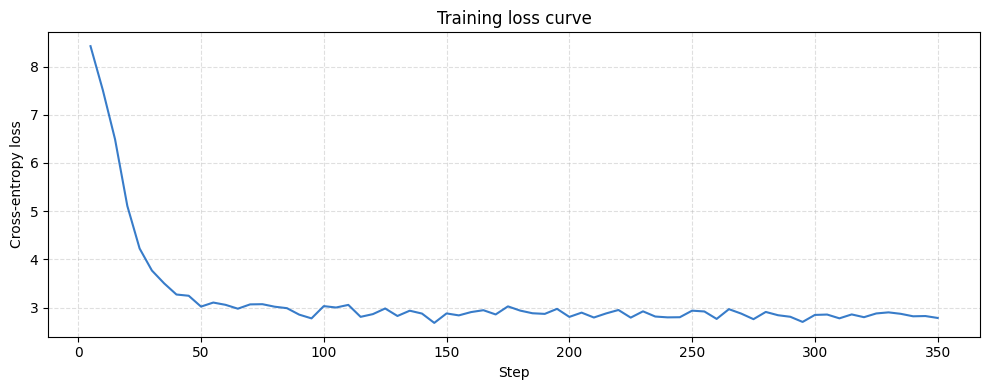

Starting loss : 8.4218
Final loss    : 2.7878
Total drop    : 5.6340

Loss is still high — consider more epochs, a lower learning rate, or checking the data format.


In [ ]:
import json, matplotlib.pyplot as plt
from pathlib import Path

ADAPTER_DIR = "/content/LLaMA-Factory/saves/Qwen3-1.7B-Base/lora/train_2026-06-25-15-58-43"  # <-- CHANGE THIS
MERGED_DIR      = "/content/qwen3_merged"
BASE_MODEL_NAME = "Qwen/Qwen3-1.7B-Base"

log_file = Path(ADAPTER_DIR) / "trainer_log.jsonl"
if not log_file.exists():
    raise FileNotFoundError(f"trainer_log.jsonl not found in {ADAPTER_DIR!r}")

records = [json.loads(l) for l in log_file.read_text().splitlines() if l.strip()]
steps   = [r["current_steps"] for r in records if r.get("loss") is not None]
losses  = [r["loss"]          for r in records if r.get("loss") is not None]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(steps, losses, linewidth=1.5, color="#1565C0", alpha=0.85)
ax.set_xlabel("Step")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Training loss curve")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("/content/training_curve.png", dpi=120)
plt.show()

total_drop = losses[0] - losses[-1]
print(f"Starting loss : {losses[0]:.4f}")
print(f"Final loss    : {losses[-1]:.4f}")
print(f"Total drop    : {total_drop:.4f}")
print()
if losses[-1] < 0.5:
    print("Loss is low — model has likely converged well.")
elif losses[-1] < 1.2:
    print("Loss is moderate — model has learned but may benefit from more epochs.")
else:
    print("Loss is still high — consider more epochs, a lower learning rate, or checking the data format.")


---
## Merge Adapter Weights, Measure Baseline & Prepare for Inference

### What is a LoRA adapter and why do we need to merge it?

During fine-tuning, the original model weights were **frozen**. Instead of updating the full weight matrices (billions of parameters), LoRA injects small, trainable rank-decomposition matrices alongside the frozen ones. Only those lightweight matrices — a tiny fraction of the total parameter count — were updated during training.

After training you therefore have two separate things on disk:
- The original **base model** weights (unchanged)
- The **LoRA adapter** — a small set of delta weights that encode everything the model learned

For training this separation is efficient. For inference it adds overhead: the model must apply the adapter at every forward pass. **Merging** folds the adapter deltas mathematically back into the base weights, producing a single standalone model that is identical in behaviour to the adapted one but has no runtime overhead and can be used anywhere that accepts a standard model.

### Why measure the baseline here?

To evaluate what fine-tuning actually contributed, we need a **control**: the same base model, on the same validation tickets, with **no fine-tuning applied**. We run this measurement right now — before attaching the LoRA adapter — because the base model is already loaded into GPU memory. Running baseline inference here costs nothing extra; skipping it and reloading later would waste time and VRAM.

### What this cell does, in order

1. Load the base model into GPU memory
2. Run **zero-shot baseline inference** on the held-out validation split → stores `y_pred_base` and `y_true`
3. Print the baseline classification report
4. Attach the LoRA adapter to the same base model
5. Call `merge_and_unload()` — folds the adapter into the weights and returns a clean standalone model
6. Save the merged model to disk as a reusable checkpoint
7. Delete all intermediate objects (base model, adapter, peft wrapper) to free VRAM
8. Leave the merged model (`_model`) live in memory, ready for the next cell

Merging LoRA adapters ("writing model shards...") will take a longer time for larger models


In [ ]:
import os, gc, json, torch, pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftConfig, get_peft_model
from peft.utils import set_peft_model_state_dict
import safetensors.torch as st

# ── USER INPUT ─────────────────────────────────────────────────────────────────

LABEL_TOKENS = [
    "Support general", "Fileservice", "O365", "EOL",
    "Software", "Active Directory", "Computer-Services",
]
CHOICES      = "ABCDEFG"
CHOICE2LABEL = {ch: lbl for ch, lbl in zip(CHOICES, LABEL_TOKENS)}

BASE_SYSTEM_PROMPT = (
    "You are an IT helpdesk ticket routing assistant. "
    "Classify the ticket by responding with ONLY a single letter — nothing else:\n"
    + "\n".join(f"{ch}) {lbl}" for ch, lbl in CHOICE2LABEL.items())
)

# ── Validate adapter ──────────────────────────────────────────────────────────
adapter_path = Path(ADAPTER_DIR)
if not adapter_path.is_dir():
    raise FileNotFoundError(f"Adapter folder not found: {ADAPTER_DIR!r}")
if not (adapter_path / "adapter_config.json").exists():
    raise FileNotFoundError(f"No adapter_config.json in {ADAPTER_DIR!r}")
print(f"Adapter found: {ADAPTER_DIR}")

# ── Device ────────────────────────────────────────────────────────────────────
HAS_CUDA = torch.cuda.is_available()
HAS_MPS  = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
DEVICE   = "cuda" if HAS_CUDA else ("mps" if HAS_MPS else "cpu")
dtype    = torch.float16 if DEVICE in ("cuda", "mps") else torch.float32
print(f"Device: {DEVICE}")

# ── Load base model + tokenizer ───────────────────────────────────────────────
print("\nLoading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME, torch_dtype=dtype, device_map=DEVICE,
)
tok_src    = str(adapter_path) if (adapter_path / "tokenizer.json").exists() else BASE_MODEL_NAME
_tokenizer = AutoTokenizer.from_pretrained(tok_src)
base_model.eval()

# ── Baseline inference on val split ───────────────────────────────────────────
_choice_ids = []
for ch in CHOICES:
    ids_plain  = _tokenizer.encode(ch,       add_special_tokens=False)
    ids_spaced = _tokenizer.encode(f" {ch}", add_special_tokens=False)
    _choice_ids.append(ids_spaced[0] if len(ids_spaced) == 1 else ids_plain[0])


def classify_base(ticket_text: str) -> str:
    messages = [
        {"role": "system", "content": BASE_SYSTEM_PROMPT},
        {"role": "user",   "content": f"Support Ticket: {ticket_text}"},
    ]
    prompt = _tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = _tokenizer(prompt, return_tensors="pt").to(base_model.device)
    with torch.no_grad():
        out = base_model(input_ids=inputs["input_ids"])
    first_logits = out.logits[0, -1, :]
    choice_probs = torch.softmax(first_logits[_choice_ids], dim=-1).cpu().tolist()
    return CHOICE2LABEL[CHOICES[choice_probs.index(max(choice_probs))]]


df_val      = pd.read_csv("/content/val_split.csv")
y_true      = df_val["label"].tolist()
y_pred_base = []

for _, row in tqdm(df_val.iterrows(), total=len(df_val), desc="Baseline inference"):
    y_pred_base.append(classify_base(row["text"]))

from sklearn.metrics import classification_report
print("\n=== Baseline (no fine-tuning) ===")
print(classification_report(y_true, y_pred_base, target_names=LABEL_TOKENS, digits=3, zero_division=0))

# ── Attach LoRA + load weights ────────────────────────────────────────────────
print("Attaching LoRA adapter...")
peft_cfg   = PeftConfig.from_pretrained(str(adapter_path))
peft_model = get_peft_model(base_model, peft_cfg)

candidates = [
    adapter_path / "adapter_model.safetensors",
    adapter_path / "adapters.safetensors",
    adapter_path / "adapter_model.bin",
]
weights_file = next((p for p in candidates if p.exists()), None)
if weights_file is None:
    raise FileNotFoundError(f"No adapter weights in {ADAPTER_DIR}")

if weights_file.suffix == ".safetensors":
    adapter_weights = st.load_file(str(weights_file), device=DEVICE)
else:
    adapter_weights = torch.load(str(weights_file), map_location=DEVICE)

set_peft_model_state_dict(peft_model, adapter_weights)

# ── Merge + save to disk ──────────────────────────────────────────────────────
print("Merging (this may take a while) ...")
_model = peft_model.merge_and_unload()

os.makedirs(MERGED_DIR, exist_ok=True)
_model.save_pretrained(MERGED_DIR)
_tokenizer.save_pretrained(MERGED_DIR)
stale = Path(MERGED_DIR) / "adapter_config.json"
if stale.exists():
    stale.unlink()
print(f"Saved → {MERGED_DIR}")

# ── Drop intermediates, keep _model in place ──────────────────────────────────
del peft_model, base_model, adapter_weights
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

_model.eval()
print("Model ready for inference.")


Adapter found: /content/LLaMA-Factory/saves/Qwen3-1.7B-Base/lora/train_2026-06-25-15-58-43
Device: cuda

Loading base model...


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Baseline inference:   0%|          | 0/117 [00:00<?, ?it/s]


=== Baseline (no fine-tuning) ===
                   precision    recall  f1-score   support

  Support general      0.000     0.000     0.000         9
      Fileservice      0.500     0.125     0.200         8
             O365      0.000     0.000     0.000        12
              EOL      0.400     0.357     0.377        28
         Software      0.000     0.000     0.000        18
 Active Directory      0.000     0.000     0.000        12
Computer-Services      0.289     0.867     0.433        30

         accuracy                          0.316       117
        macro avg      0.170     0.193     0.144       117
     weighted avg      0.204     0.316     0.215       117

Attaching LoRA adapter...
Merging (this may take a while) ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

---
## Define `classify()` and Smoke Test the Merged Model

### How inference works

The merged model is a standard causal language model. At inference time we:

1. Format the support ticket as a **chat prompt** using the same template the model was trained on — a system message describing the task, followed by the user's ticket text
2. Pass the prompt to the model and let it **generate** the next tokens
3. Read the first generated token(s) and match them to one of the seven routing labels

We cap generation at 10 new tokens. For a well-trained router, the correct label appears in the very first token — the model should be that confident. The `classify()` function also returns a **confidence score**: the softmax probability assigned to the winning label's first token versus the other six candidates. A score above ~85% generally indicates the model is routing with high certainty; lower scores flag ambiguous tickets worth human review.

### Why a smoke test before the full evaluation?

The five smoke-test tickets cover five of the seven classes with unambiguous phrasing. If any of them are wrong, something is broken — the wrong checkpoint was loaded, the chat template doesn't match, or training diverged. The smoke test is a fast sanity check before committing to the full val-set evaluation loop.


In [ ]:
import torch

SYSTEM_PROMPT = (
    "You are an IT helpdesk ticket routing assistant. "
    "Given a support ticket, respond with exactly one of the following categories: "
    "Support general, Fileservice, O365, EOL, Software, Active Directory, Computer-Services."
)
LABEL_TOKENS = [
    "Support general", "Fileservice", "O365", "EOL",
    "Software", "Active Directory", "Computer-Services",
]


def classify(ticket_text: str, compute_confidence: bool = True) -> tuple:
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": f"Support Ticket: {ticket_text}"},
    ]
    prompt = _tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = _tokenizer(prompt, return_tensors="pt").to(_model.device)

    with torch.no_grad():
        out = _model.generate(
            **inputs,
            max_new_tokens=10,
            do_sample=False,
            output_scores=True,
            return_dict_in_generate=True,
            pad_token_id=_tokenizer.eos_token_id,
        )

    generated = _tokenizer.decode(
        out.sequences[0][inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True,
    ).strip()

    matched = next((l for l in LABEL_TOKENS if generated.lower().startswith(l.lower())), None)
    if matched is None:
        matched = "Support general"

    if not compute_confidence or not out.scores:
        return matched, 1.0

    first_scores    = out.scores[0][0]
    label_first_ids = [_tokenizer.encode(l, add_special_tokens=False)[0] for l in LABEL_TOKENS]
    label_probs     = torch.softmax(first_scores[label_first_ids], dim=-1).cpu().tolist()
    conf = label_probs[LABEL_TOKENS.index(matched)]
    return matched, conf


# ── Smoke test ────────────────────────────────────────────────────────────────
smoke_tickets = [
    ("Please create a new user account for the new employee starting Monday.",    "Active Directory"),
    ("I cannot access the shared network folder — I keep getting Access Denied.", "Fileservice"),
    ("Outlook keeps asking me to re-enter my password and Teams won't sync.",    "O365"),
    ("We're ready to retire [SERVER] — please remove it from monitoring.",       "EOL"),
    ("Adobe Acrobat fails to install, error code 1603.",                           "Software"),
]

print(f"\n{'Ticket (truncated)':<60} {'Expected':<20} {'Predicted':<20} {'Conf':>6}")
print("-" * 108)
for ticket, expected in smoke_tickets:
    label, conf = classify(ticket)
    ok = "OK" if label == expected else "--"
    print(f"{ticket[:58]:<60} {expected:<20} {label:<20} {conf:>6.1%}  {ok}")


---
## Evaluate the Fine-tuned Model on the Validation Split

The validation split was held out during training — the model has never seen these tickets. Running inference on them gives an honest estimate of real-world routing performance.

We run `classify()` on every row of `df_val`, collecting predicted labels into `y_pred`. Combined with `y_true` (the ground-truth labels set when the base model was loaded), these two lists feed into all the metrics below.

**Note:** confidence scores are skipped here (`compute_confidence=False`) to keep the evaluation loop fast. Confidence is shown in the classification report sample and smoke test.

In [ ]:
# --- 5.3  Evaluate fine-tuned model on val split ----------------------------
from tqdm.auto import tqdm

y_pred = []
for _, row in tqdm(df_val.iterrows(), total=len(df_val), desc="Fine-tuned inference"):
    pred, _ = classify(row["text"], compute_confidence=False)
    y_pred.append(pred)

print(f"Evaluated {len(y_pred):,} samples.")


In [ ]:
# --- 5.4  Classification report ---------------------------------------------
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=LABEL_TOKENS, digits=3))

# Show a few val examples with predictions
print()
for i in [0, 10, 20, 30]:
    row  = df_val.iloc[i]
    pred, conf = classify(row["text"])
    print(f"=== Ticket {i}")
    print(f"TRUE label: {row['label']}")
    print(f"PRED label: {pred}  (conf {conf:.1%})")
    print()

### Reading the classification report

The report shows four numbers per class:

| Metric | What it measures |
|--------|-----------------|
| **Precision** | Of all tickets the model routed to this class, what fraction actually belonged there — measures false alarm rate |
| **Recall** | Of all tickets that truly belong to this class, what fraction did the model catch — measures miss rate |
| **F1** | Harmonic mean of precision and recall — a single balanced score per class |
| **Support** | Number of validation tickets in this class |

### Routing cost asymmetry

Overall accuracy treats every mistake equally. In a real helpdesk, they are not equal.

An `Active Directory` ticket misrouted means a new employee cannot log in on their first day — high urgency, immediately visible to the business. A `Fileservice` ticket in the general queue delays access to shared files — serious, but less acute. A `Support general` ticket misrouted wastes a specialist's time, but no critical system is blocked.

**The metric that matters for production: per-class recall on high-urgency categories.**

A model with 90% overall accuracy but 60% `Active Directory` recall is routing 40% of account-provisioning requests to the wrong team. A model with 83% overall accuracy and 95% `Active Directory` recall is safer, even though it looks worse on the headline number. This is why the confusion matrix and per-class F1 are more informative than a single accuracy figure for any triage or routing problem.

### Confusion matrix

The confusion matrix shows **where the model makes mistakes**, not just how many. Each row is a true class; each column is what the model predicted. The diagonal is correct predictions; everything off-diagonal is an error.

The colour is row-normalised (each row sums to 1.0), so you can immediately see recall per class — a dark diagonal cell means high recall. The raw counts are printed inside each cell so you can judge statistical significance: a single confused ticket out of eight is less meaningful than five out of eight.

Look for systematic off-diagonal patterns: if `Active Directory` tickets frequently land in `Support general`, that is a specific confusion pair worth addressing — perhaps those tickets lack enough signal, or training data for that pair was too sparse.

In [ ]:
# --- 5.5  Confusion matrix --------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm      = confusion_matrix(y_true, y_pred, labels=LABEL_TOKENS)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm_norm, annot=cm, fmt="d", cmap="Blues",
    xticklabels=LABEL_TOKENS, yticklabels=LABEL_TOKENS,
    linewidths=0.5, ax=ax,
)
ax.set_title("Confusion matrix (counts shown, colour = row-normalised recall)")
ax.set_ylabel("True label")
ax.set_xlabel("Predicted label")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=120)
plt.show()

ad_recall   = cm_norm[LABEL_TOKENS.index("Active Directory"),   LABEL_TOKENS.index("Active Directory")]
file_recall = cm_norm[LABEL_TOKENS.index("Fileservice"),        LABEL_TOKENS.index("Fileservice")]
print(f"\nActive Directory recall : {ad_recall:.1%}")
print(f"Fileservice recall      : {file_recall:.1%}")
if ad_recall < 0.85:
    print("Warning: Active Directory recall below 0.85 — consider training longer.")

---
## Baseline vs Fine-tuned Comparison

### What "baseline" means here

The baseline is the same model weights that fine-tuning started from, evaluated on the same validation tickets, with **zero task-specific training**. It represents what the model knows purely from pre-training — general language understanding, instruction-following, some domain knowledge absorbed from internet text — with no exposure to your labelled examples.

### Why a letter-choice prompt for the baseline?

A naive baseline would ask the model to generate the label string directly. The problem is that the untrained model has no reason to prefer exactly `"Active Directory"` over `"active directory"`, `"AD"`, or a full sentence. Matching would fail unpredictably.

Instead we use a **constrained multiple-choice format**: present seven options labelled A–G and compare the logit scores of those seven single tokens at the first generation step. Single letters are unambiguous, single-token outputs in any tokenizer — the comparison is clean and the result is always a valid label. This gives the base model its best possible shot, making the comparison fair.

### What the delta tells you

The gap between baseline and fine-tuned accuracy is the direct, measurable value of the labelled training data and the fine-tuning run. A large delta on classes that were near-zero in the baseline confirms the model genuinely learned task-specific routing signal, not just pattern-matching it already knew.

### Reading the comparison chart

Each class has two bars: light blue for the base model, dark blue for the fine-tuned model. The rightmost pair shows overall accuracy.

Things to look for:

- **Classes where the base model scores zero** — the base model has no idea how to route those tickets; fine-tuning taught everything it knows about them
- **Classes where the gap is small** — the base model already had strong signal (often classes whose names closely match common language, like `Software`)
- **Classes where the fine-tuned model regressed** — rare, but possible if that class was underrepresented in training or if the labels were ambiguous
- **The overall accuracy delta** — the headline number printed below the chart; typical values after a short LoRA run on a small dataset are in the +40–60 percentage point range

In [ ]:
# --- 5.7b  Comparison chart: baseline vs fine-tuned ------------------------
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, accuracy_score


def per_class_f1(y_t, y_p, labels):
    report = classification_report(y_t, y_p, target_names=labels, output_dict=True, zero_division=0)
    return {lbl: report[lbl]["f1-score"] for lbl in labels}


ft_f1    = per_class_f1(y_true, y_pred,      LABEL_TOKENS)
base_f1  = per_class_f1(y_true, y_pred_base, LABEL_TOKENS)
ft_acc   = accuracy_score(y_true, y_pred)
base_acc = accuracy_score(y_true, y_pred_base)

labels_plot = LABEL_TOKENS + ["overall accuracy"]
ft_vals     = [ft_f1[l]   for l in LABEL_TOKENS] + [ft_acc]
base_vals   = [base_f1[l] for l in LABEL_TOKENS] + [base_acc]

x     = np.arange(len(labels_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars_base = ax.bar(x - width/2, base_vals, width, label="Base model (no fine-tuning)", color="#90CAF9", edgecolor="white")
bars_ft   = ax.bar(x + width/2, ft_vals,   width, label="Fine-tuned (LLaMA Board LoRA)", color="#1565C0", edgecolor="white")

ax.bar_label(bars_base, fmt="{:.2f}", padding=3, fontsize=8)
ax.bar_label(bars_ft,   fmt="{:.2f}", padding=3, fontsize=8)
bars_base[-1].set_color("#FFCC80")
bars_ft[-1].set_color("#E65100")

ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels([l.replace(" ", "\n") for l in labels_plot], fontsize=9)
ax.set_ylabel("F1 score  /  Accuracy")
ax.set_title("Support ticket router — Baseline vs Fine-tuned (per-class F1 + overall accuracy)")
ax.legend()
ax.axvline(len(LABEL_TOKENS) - 0.5, color="grey", linestyle="--", linewidth=0.8)
ax.text(len(LABEL_TOKENS) - 0.5 + 0.05, 1.08, "overall", fontsize=8, color="grey")
plt.tight_layout()
plt.savefig("/content/baseline_vs_finetuned.png", dpi=120)
plt.show()

print(f"\nBase accuracy  : {base_acc:.1%}")
print(f"Fine-tuned acc : {ft_acc:.1%}")
print(f"Delta          : +{(ft_acc - base_acc):.1%}")